# 수행평가 종료 후 보여 줄 다른 시각화 예시

학생이 사용한 것과 같은 평가 CSV를 읽어 네 가지 관점으로 시각화한다. 각 셀의 실행 결과를 PPT의 예시 화면으로 사용한다.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]
CSV_PATH = ROOT / '05/sample/data/05-data-1-school-facility-usage.csv'
OUTPUT_DIR = ROOT / 'assets/img'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

font_candidates = [
    Path.home() / 'Library/Fonts/IBMPlexSansKR-Regular.ttf',
    Path('C:/Windows/Fonts/malgun.ttf'),
]
for font_path in font_candidates:
    if font_path.exists():
        font_manager.fontManager.addfont(font_path)
        mpl.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
        break
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'

INK = '#1B1D21'
ORANGE = '#FF5C00'
TEAL = '#0B8995'
GREY = '#F1F2F4'
LINE = '#E0E3E7'
MUTED = '#69707A'
WEEKDAYS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
WEEKDAY_LABELS = ['월', '화', '수', '목', '금']
FACILITY_LABELS = {
    'Gym': '체육관', 'Computer_Room': '컴퓨터실', 'Library': '도서관',
    'Music_Room': '음악실', 'Science_Lab': '과학실', 'Art_Room': '미술실',
}

df = pd.read_csv(CSV_PATH)
assert len(df) == 12_960
print(f'평가 CSV를 읽었습니다: {len(df):,}행 · {len(df.columns)}열')

평가 CSV를 읽었습니다: 12,960행 · 5열


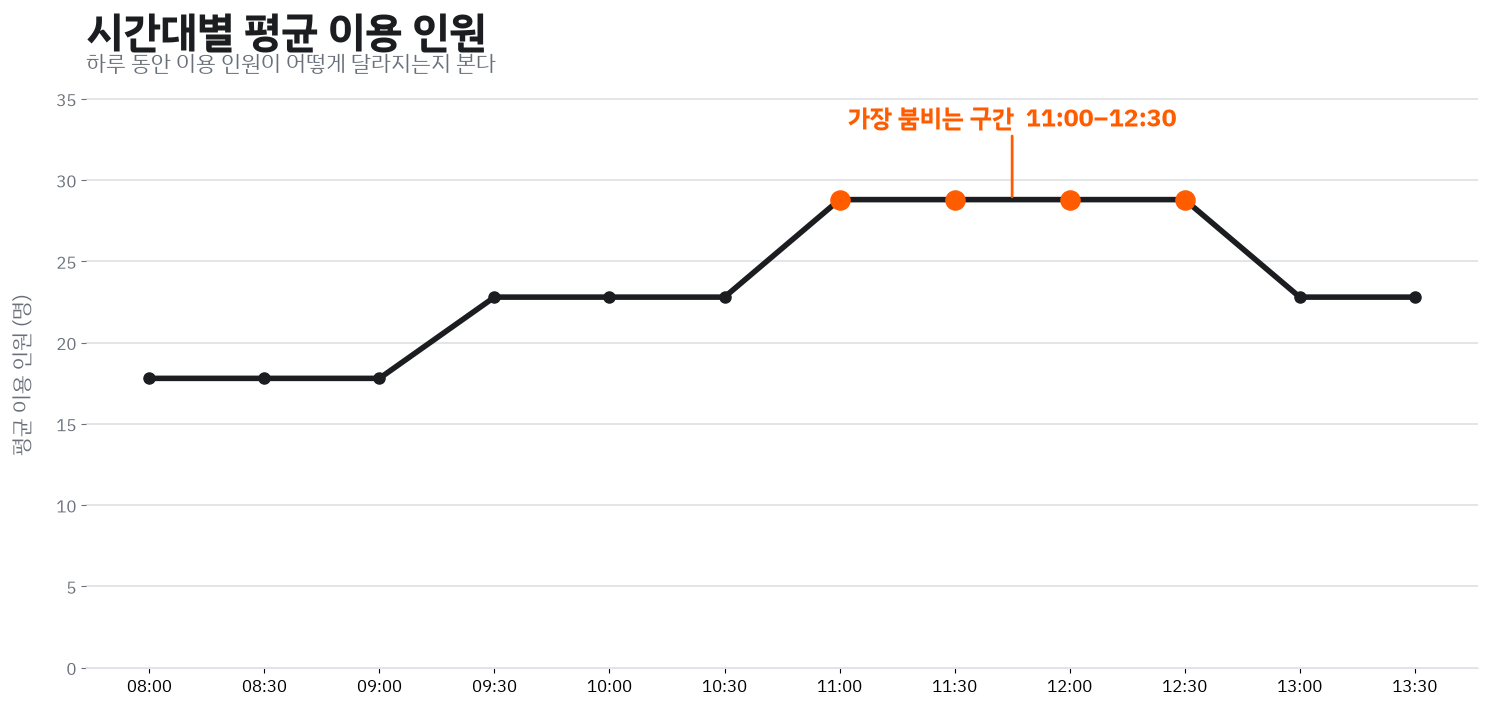

In [2]:
# 1. 시간대가 바뀔 때 평균 이용 인원이 어떻게 달라지는지 본다.
time_mean = df.groupby('time_slot', sort=False)['visitors'].mean()
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
x = np.arange(len(time_mean))
ax.plot(x, time_mean.values, color=INK, linewidth=4, marker='o', markersize=8)
peak = time_mean.max()
peak_idx = np.flatnonzero(time_mean.values == peak)
ax.scatter(peak_idx, time_mean.values[peak_idx], s=190, color=ORANGE, zorder=3)
ax.annotate(
    f'가장 붐비는 구간  {time_mean.index[peak_idx[0]]}–{time_mean.index[peak_idx[-1]]}',
    xy=(peak_idx.mean(), peak), xytext=(peak_idx.mean(), peak + 4.5),
    ha='center', color=ORANGE, fontsize=18, fontweight='bold',
    arrowprops={'arrowstyle': '-', 'color': ORANGE, 'linewidth': 2},
)
ax.set_title('시간대별 평균 이용 인원', loc='left', fontsize=30, fontweight='bold', color=INK, pad=26)
ax.text(0, 1.02, '하루 동안 이용 인원이 어떻게 달라지는지 본다', transform=ax.transAxes, fontsize=16, color=MUTED)
ax.set_ylabel('평균 이용 인원 (명)', fontsize=15, color=MUTED, labelpad=18)
ax.set_xticks(x, time_mean.index, fontsize=12)
ax.tick_params(axis='y', labelsize=12, colors=MUTED)
ax.grid(axis='y', color=LINE, linewidth=1.3)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(LINE)
ax.set_ylim(0, max(36, peak + 7))
fig.subplots_adjust(left=0.09, right=0.96, bottom=0.13, top=0.78)
fig.savefig(OUTPUT_DIR / '05-2-02-time-slot-average.png', dpi=100, facecolor='white')
plt.show()

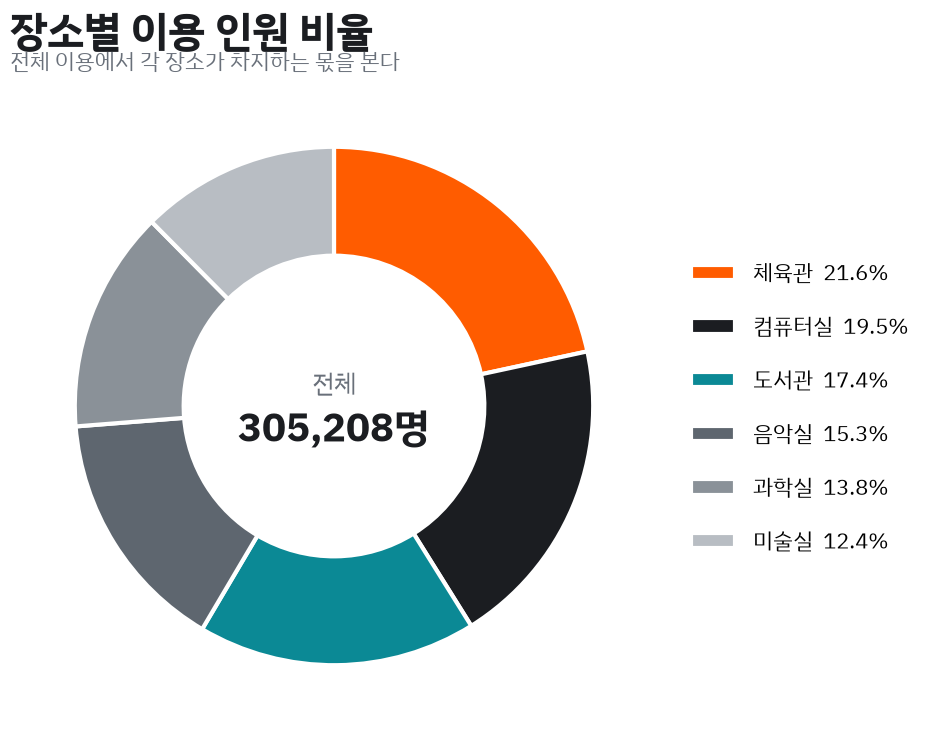

In [3]:
# 2. 전체 이용에서 각 장소가 차지하는 비율을 본다.
facility_total = df.groupby('facility')['visitors'].sum().sort_values(ascending=False)
labels = [FACILITY_LABELS[name] for name in facility_total.index]
colors = [ORANGE, INK, TEAL, '#5E666F', '#8A9198', '#B8BDC3']
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
wedges, _ = ax.pie(
    facility_total.values, startangle=90, counterclock=False, colors=colors,
    wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 3},
)
ax.text(0, 0.09, '전체', ha='center', va='center', fontsize=18, color=MUTED)
ax.text(0, -0.08, f'{facility_total.sum():,}명', ha='center', va='center', fontsize=29, fontweight='bold', color=INK)
ax.legend(
    wedges, [f'{label}  {value / facility_total.sum() * 100:.1f}%' for label, value in zip(labels, facility_total.values)],
    loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=16, labelspacing=1.4,
)
ax.set_title('장소별 이용 인원 비율', loc='left', fontsize=30, fontweight='bold', color=INK, pad=26)
ax.text(0, 1.02, '전체 이용에서 각 장소가 차지하는 몫을 본다', transform=ax.transAxes, fontsize=16, color=MUTED)
ax.set_aspect('equal')
fig.subplots_adjust(left=0.08, right=0.76, bottom=0.08, top=0.80)
fig.savefig(OUTPUT_DIR / '05-2-03-facility-share.png', dpi=100, facecolor='white')
plt.show()

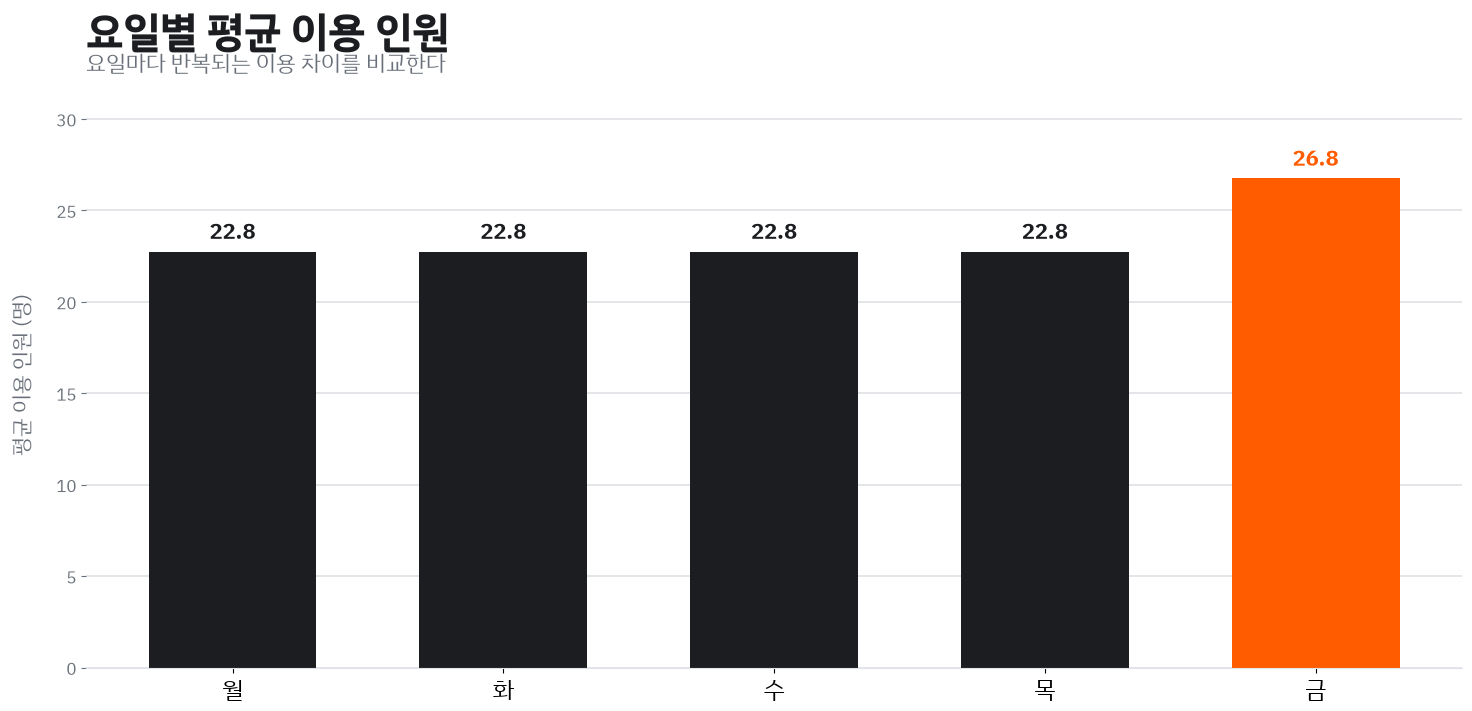

In [4]:
# 3. 요일별 평균을 비교해 반복되는 차이를 본다.
weekday_mean = df.groupby('weekday')['visitors'].mean().reindex(WEEKDAYS)
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
bars = ax.bar(WEEKDAY_LABELS, weekday_mean.values, color=[INK, INK, INK, INK, ORANGE], width=0.62)
for bar, value in zip(bars, weekday_mean.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.7, f'{value:.1f}', ha='center', fontsize=16, fontweight='bold', color=bar.get_facecolor())
ax.set_title('요일별 평균 이용 인원', loc='left', fontsize=30, fontweight='bold', color=INK, pad=26)
ax.text(0, 1.02, '요일마다 반복되는 이용 차이를 비교한다', transform=ax.transAxes, fontsize=16, color=MUTED)
ax.set_ylabel('평균 이용 인원 (명)', fontsize=15, color=MUTED, labelpad=18)
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=12, colors=MUTED)
ax.grid(axis='y', color=LINE, linewidth=1.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(LINE)
ax.set_ylim(0, max(32, weekday_mean.max() + 5))
fig.subplots_adjust(left=0.10, right=0.96, bottom=0.13, top=0.78)
fig.savefig(OUTPUT_DIR / '05-2-04-weekday-average.png', dpi=100, facecolor='white')
plt.show()

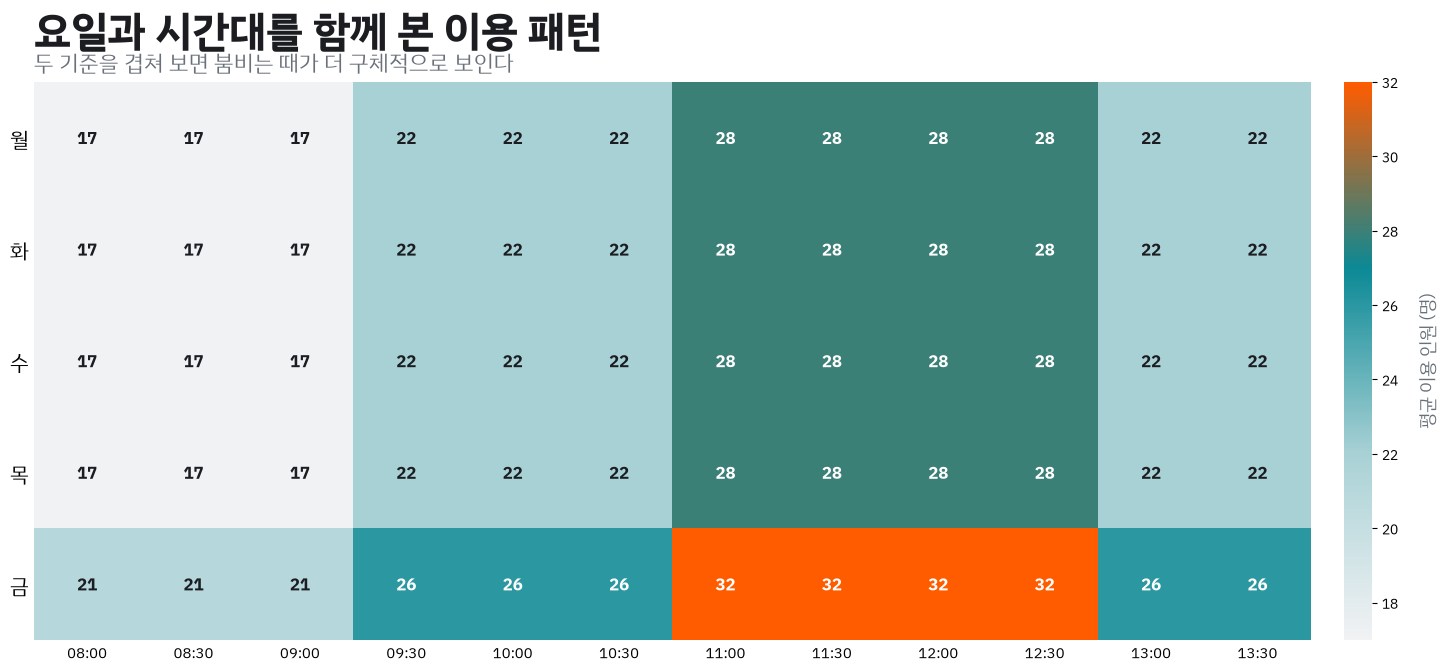

In [5]:
# 4. 요일과 시간대를 함께 놓아 두 기준의 관계를 본다.
heat = df.pivot_table(index='weekday', columns='time_slot', values='visitors', aggfunc='mean').reindex(WEEKDAYS)
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
cmap = mpl.colors.LinearSegmentedColormap.from_list('school', [GREY, '#A8D1D5', TEAL, ORANGE])
image = ax.imshow(heat.values, cmap=cmap, aspect='auto', vmin=heat.values.min(), vmax=heat.values.max())
for row in range(heat.shape[0]):
    for col in range(heat.shape[1]):
        value = heat.iat[row, col]
        ax.text(col, row, f'{value:.0f}', ha='center', va='center', fontsize=12, fontweight='bold', color='white' if value >= 25 else INK)
ax.set_xticks(np.arange(heat.shape[1]), heat.columns, fontsize=11)
ax.set_yticks(np.arange(heat.shape[0]), WEEKDAY_LABELS, fontsize=15)
ax.set_title('요일과 시간대를 함께 본 이용 패턴', loc='left', fontsize=30, fontweight='bold', color=INK, pad=26)
ax.text(0, 1.02, '두 기준을 겹쳐 보면 붐비는 때가 더 구체적으로 보인다', transform=ax.transAxes, fontsize=16, color=MUTED)
ax.tick_params(length=0)
ax.spines[:].set_visible(False)
colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.025)
colorbar.set_label('평균 이용 인원 (명)', fontsize=13, color=MUTED, labelpad=14)
colorbar.outline.set_visible(False)
fig.subplots_adjust(left=0.09, right=0.93, bottom=0.14, top=0.76)
fig.savefig(OUTPUT_DIR / '05-2-05-weekday-time-heatmap.png', dpi=100, facecolor='white')
plt.show()